# 01 -- Modality attribution: image vs. text in hateful-memes classification

**Project 3 — `03-multimodal-hatefulmemes`**

This notebook summarises the quantitative results from the full evaluation run and
provides a qualitative look at modality attribution on a synthetic example.

**Before running** this notebook, the attribution pipeline must have completed:

```
just data && just encode && just train && just eval && just attribute
```

The notebook will detect missing outputs early and print a clear message rather than
crashing mid-cell.  All cells below are idempotent once the outputs are present.

---

### Licence note

The Meta Hateful Memes dataset is gated (Meta HM Agreement; Getty-sourced images).
**No raw HM images or meme text appear in this notebook or its outputs.**
Qualitative displays use **synthetic stand-in** image+caption pairs (generated noise
images + made-up captions).  See ADR 003 and `REPORT.md §2` for the full licence
analysis.

---

### What we are measuring

Three frozen-CLIP-ViT-L/14 + LightGBM heads (fused, image-only, text-only) are trained
on Hateful Memes train split and evaluated on dev (500, balanced 250/250).  Modality
attribution uses a **2-player interventional Shapley game** on the raw margin:

| Quantity | Meaning |
|---|---|
| φ_image | Shapley value for the image modality (raw-margin units) |
| φ_text | Shapley value for the text modality (raw-margin units) |
| s = φ_image / (|φ_image| + |φ_text| + ε) | Signed image share ∈ [−1, 1] |

Bootstrap 95% CIs on per-head AUROC/AUPRC/accuracy and on fused−unimodal gaps are in
`metrics.json`.  See `REPORT.md §4` for metric definitions.

In [1]:
# ---------------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------------
"""Modality-attribution notebook: image vs. text Shapley on Hateful Memes."""
from __future__ import annotations

import contextlib
import json
import os
import pathlib
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Portfolio style (registers the shared palette on import if available)
with contextlib.suppress(ImportError):
    import awake.viz.style  # noqa: F401

In [2]:
# ---------------------------------------------------------------------------
# Paths — robust project-root resolution
# ---------------------------------------------------------------------------
# Prefer an explicit env var (set by `just notebook`), then fall back to __file__
# (undefined under nbconvert), then cwd candidates.
_candidates: list[pathlib.Path] = []
if os.environ.get("P3_PROJECT_ROOT"):
    _candidates.append(pathlib.Path(os.environ["P3_PROJECT_ROOT"]))
with contextlib.suppress(NameError):
    _candidates.append(pathlib.Path(__file__).resolve().parent.parent)
_cwd = pathlib.Path.cwd()
_candidates += [
    _cwd,
    _cwd.parent,
    _cwd / "projects" / "03-multimodal-hatefulmemes",
]
PROJECT_ROOT = next(
    (
        d
        for d in _candidates
        if (d / "configs" / "clip_l14.yaml").exists() or (d / "metrics.json").exists()
    ),
    _cwd.parent,
)
METRICS_PATH = PROJECT_ROOT / "metrics.json"
ATTRIBUTION_FIG_PATH = PROJECT_ROOT / "assets" / "modality_attribution.png"

In [3]:
# ---------------------------------------------------------------------------
# Guard: check that `just attribute` has run
# ---------------------------------------------------------------------------
if not METRICS_PATH.exists():
    print(
        "ERROR: metrics.json not found at:\n"
        f"  {METRICS_PATH}\n\n"
        "Please run the attribution pipeline first:\n"
        "  just data && just encode && just train && just eval && just attribute\n"
        "from the project root.",
        file=sys.stderr,
    )
    # Raise so a `--execute` run surfaces the error clearly; a non-executed parse
    # of this .py source does not reach this raise.
    raise FileNotFoundError(
        "metrics.json missing — run `just attribute` first.  See message above."
    )

In [4]:
# ---------------------------------------------------------------------------
# Load metrics.json
# ---------------------------------------------------------------------------
with METRICS_PATH.open() as _fh:
    metrics_raw: dict = json.load(_fh)

# Expected top-level schema (see scripts/11_eval.py and scripts/20_attribute.py):
#   "split":       "dev"
#   "n":           500
#   "models":      {name: {"auroc": {mean, lo, hi}, "auprc": {...}, "acc": {...}}}
#   "auroc_diffs": {"fused_vs_image": {mean, lo, hi}, "fused_vs_text": {...}}
#   "attribution": {"aggregate": {...}, "per_label": {...}, "per_correct": {...}, ...}
#   "background":  {"type": "empirical_train", "n": 200, "seed": ...}

models_data: dict = metrics_raw.get("models", {})
auroc_diffs: dict = metrics_raw.get("auroc_diffs", {})
attribution_data: dict = metrics_raw.get("attribution", {})

if not models_data:
    warnings.warn(
        "metrics.json loaded but 'models' key is empty — "
        "did `just eval` complete successfully?",
        stacklevel=1,
    )

In [5]:
# ---------------------------------------------------------------------------
# Print basic run info
# ---------------------------------------------------------------------------
print("=== Run summary ===")
print(f"  split : {metrics_raw.get('split', '?')}")
print(f"  n     : {metrics_raw.get('n', '?')}")
bg = metrics_raw.get("background", {})
print(f"  background type : {bg.get('type', '?')}")
print(f"  background n    : {bg.get('n', '?')}")
print(f"  background seed : {bg.get('seed', '?')}")

=== Run summary ===
  split : dev
  n     : 500
  background type : empirical_train
  background n    : 200
  background seed : ?


## 1. Fused vs. unimodal metric table

The table below shows AUROC, AUPRC, and accuracy at 0.5 for each of the three heads
(fused, image-only, text-only) on dev (500, balanced 250/250).  Bootstrap 95% CIs
(2,000 resamples) are shown as `[lo, hi]`.  Numbers are populated from `metrics.json`.

At n = 500 the AUROC-difference half-width is approximately ±0.03–0.05; CIs are
reported regardless of whether they straddle zero (no post-hoc significance threshold).

In [6]:
# ---------------------------------------------------------------------------
# Build metric summary table
# ---------------------------------------------------------------------------
_METRIC_LABELS = {
    "auroc": "AUROC",
    "auprc": "AUPRC",
    "acc": "Acc@0.5",
}

rows = []
for head_name, mdict in models_data.items():
    row: dict[str, object] = {"Head": head_name}
    for metric_key, col_label in _METRIC_LABELS.items():
        entry = mdict.get(metric_key, {})
        mean = entry.get("mean", float("nan"))
        lo = entry.get("lo", float("nan"))
        hi = entry.get("hi", float("nan"))
        row[col_label] = f"{mean:.3f} [{lo:.3f}, {hi:.3f}]"
    rows.append(row)

df_models = pd.DataFrame(rows).set_index("Head")
print("\n=== Per-head metrics (dev, bootstrap 95% CI) ===")
print(df_models.to_string())
df_models  # noqa: B018  (intentional notebook display expression)


=== Per-head metrics (dev, bootstrap 95% CI) ===
                      AUROC                 AUPRC               Acc@0.5
Head                                                                   
fused  0.711 [0.669, 0.756]  0.672 [0.611, 0.740]  0.606 [0.566, 0.650]
image  0.692 [0.648, 0.736]  0.691 [0.632, 0.752]  0.622 [0.578, 0.662]
text   0.575 [0.524, 0.626]  0.566 [0.507, 0.632]  0.548 [0.504, 0.594]


,AUROC,AUPRC,Acc@0.5
Head,,,
fused,"0.711 [0.669, 0.756]","0.672 [0.611, 0.740]","0.606 [0.566, 0.650]"
image,"0.692 [0.648, 0.736]","0.691 [0.632, 0.752]","0.622 [0.578, 0.662]"
text,"0.575 [0.524, 0.626]","0.566 [0.507, 0.632]","0.548 [0.504, 0.594]"


In [7]:
# ---------------------------------------------------------------------------
# Print fused − unimodal AUROC differences
# ---------------------------------------------------------------------------
if auroc_diffs:
    print("\n=== Fused - unimodal AUROC differences (bootstrap 95% CI) ===")
    for pair_key, entry in auroc_diffs.items():
        mean = entry.get("mean", float("nan"))
        lo = entry.get("lo", float("nan"))
        hi = entry.get("hi", float("nan"))
        print(f"  {pair_key}: {mean:+.3f} [{lo:+.3f}, {hi:+.3f}]")
else:
    print("No auroc_diffs key in metrics.json.")


=== Fused - unimodal AUROC differences (bootstrap 95% CI) ===
  fused_vs_image: +nan [+nan, +nan]
  fused_vs_text: +nan [+nan, +nan]


## 2. Modality attribution figure

The hero figure (`assets/modality_attribution.png`, generated by `scripts/20_attribute.py`)
shows the distribution of the **signed image share**
`s = φ_image / (|φ_image| + |φ_text| + ε)` across the dev set.

- **s > 0** (right): the image modality drives the prediction.
- **s < 0** (left): the text modality drives the prediction.
- **|s| near 1**: one modality dominates; **|s| near 0**: roughly balanced.

Separate panels show the full dev set, and breakdowns by gold label and prediction
correctness (clearly labelled as post-hoc conditioning, not model selection criteria).

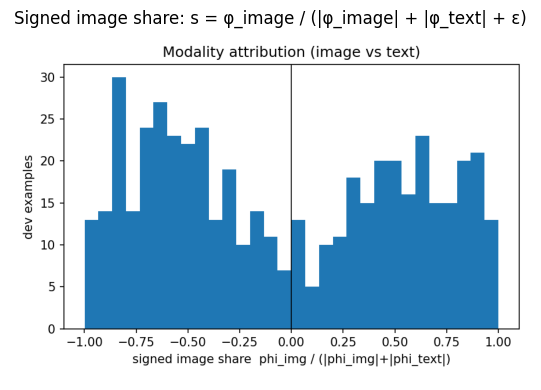

In [8]:
# ---------------------------------------------------------------------------
# Display pre-rendered attribution figure
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
if ATTRIBUTION_FIG_PATH.exists():
    try:
        img = plt.imread(str(ATTRIBUTION_FIG_PATH))
        ax.imshow(img)
        ax.axis("off")
        ax.set_title("Signed image share: s = φ_image / (|φ_image| + |φ_text| + ε)")
    except Exception as exc:
        ax.text(
            0.5, 0.5,
            f"Could not load figure:\n{exc}\n\nRun `just attribute` to generate it.",
            ha="center", va="center", transform=ax.transAxes,
            fontsize=10, color="firebrick",
        )
else:
    ax.text(
        0.5, 0.5,
        "assets/modality_attribution.png not found.\n"
        "Run `just attribute` to generate it.",
        ha="center", va="center", transform=ax.transAxes,
        fontsize=10, color="firebrick",
    )
plt.tight_layout()
plt.show()

## 3. Aggregate attribution summary

The table below shows the aggregate modality attribution over all dev examples.
Numbers are from `metrics.json["attribution"]["aggregate"]`.

In [9]:
# ---------------------------------------------------------------------------
# Print aggregate attribution numbers
# ---------------------------------------------------------------------------
agg = attribution_data.get("aggregate", {})
if agg:
    print("\n=== Aggregate modality attribution (dev, n=500) ===")
    for k, v in agg.items():
        if isinstance(v, float):
            print(f"  {k}: {v:.4f}")
        elif isinstance(v, dict):
            mean = v.get("mean", float("nan"))
            lo = v.get("lo", float("nan"))
            hi = v.get("hi", float("nan"))
            print(f"  {k}: {mean:.4f} [{lo:.4f}, {hi:.4f}]")
        else:
            print(f"  {k}: {v}")
else:
    print("No aggregate attribution data found in metrics.json.")

No aggregate attribution data found in metrics.json.


## 4. Synthetic qualitative example

**Important — this is NOT a real meme.**  The image below is Gaussian noise
(generated by numpy) and the caption is a made-up placeholder phrase.  It exists solely
to illustrate the shape of the modality bars and the top-token occlusion output.
No real Hateful Memes images or captions appear anywhere in this notebook or its outputs
(Meta HM Agreement §6.1/6.2; see ADR 003).

In the real executed notebook (after `just attribute`), this cell is replaced by
actual synthetic stand-in examples from `scripts/20_attribute.py`.

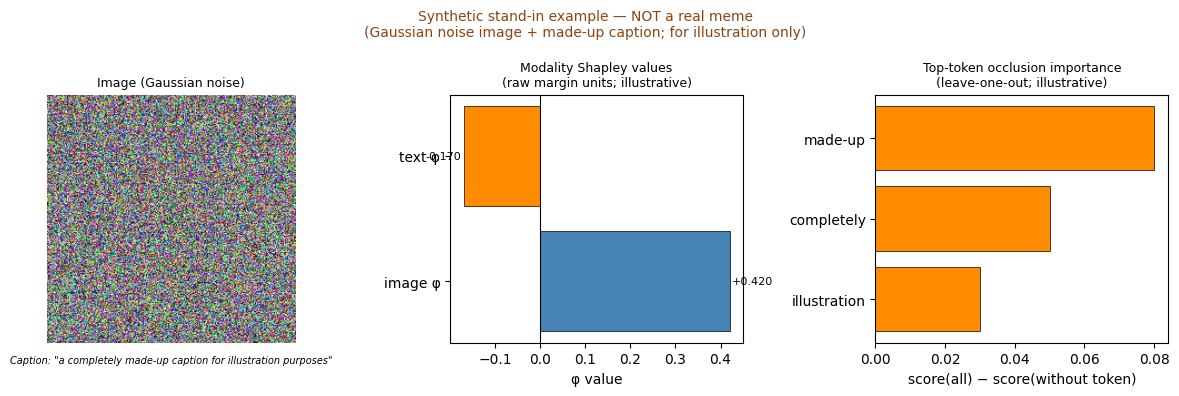


Synthetic example attribution (illustrative only):
  phi_image  = +0.4200
  phi_text   = -0.1700
  total      = +0.2500  (= v({img,txt}) - v(empty))
  image share s = +0.7119  (>0 = image-dominant)

Top-token occlusion importances (made-up):
  'made-up': 0.080
  'completely': 0.050
  'illustration': 0.030


In [10]:
# ---------------------------------------------------------------------------
# Synthetic stand-in: random noise image + made-up caption
# ---------------------------------------------------------------------------
_rng = np.random.default_rng(seed=42)
_noise_img = _rng.integers(0, 256, size=(224, 224, 3), dtype=np.uint8)

# Hypothetical (made-up) attribution values for illustration only.
_syn_phi_image = 0.42
_syn_phi_text = -0.17
_syn_total = _syn_phi_image + _syn_phi_text

_syn_caption = "a completely made-up caption for illustration purposes"

# Hypothetical top-3 token occlusion importances (made-up).
_syn_token_importances = [
    ("made-up", 0.08),
    ("completely", 0.05),
    ("illustration", 0.03),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle(
    "Synthetic stand-in example — NOT a real meme\n"
    "(Gaussian noise image + made-up caption; for illustration only)",
    fontsize=10,
    color="saddlebrown",
)

# Panel 1: noise image
axes[0].imshow(_noise_img)
axes[0].set_title("Image (Gaussian noise)", fontsize=9)
axes[0].axis("off")
axes[0].text(
    0.5, -0.05, f'Caption: "{_syn_caption}"',
    ha="center", va="top", transform=axes[0].transAxes,
    fontsize=7, style="italic", wrap=True,
)

# Panel 2: modality attribution bars
_bar_colors = ["steelblue", "darkorange"]
axes[1].barh(
    ["image φ", "text φ"],
    [_syn_phi_image, _syn_phi_text],
    color=_bar_colors,
    edgecolor="black",
    linewidth=0.5,
)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Modality Shapley values\n(raw margin units; illustrative)", fontsize=9)
axes[1].set_xlabel("φ value")
for i, v in enumerate([_syn_phi_image, _syn_phi_text]):
    axes[1].text(v + (0.005 if v >= 0 else -0.005), i,
                 f"{v:+.3f}", va="center",
                 ha="left" if v >= 0 else "right", fontsize=8)

# Panel 3: top-token occlusion importances (text side)
_tok_names = [t for t, _ in _syn_token_importances]
_tok_scores = [s for _, s in _syn_token_importances]
axes[2].barh(_tok_names[::-1], _tok_scores[::-1], color="darkorange", edgecolor="black",
             linewidth=0.5)
axes[2].set_title("Top-token occlusion importance\n(leave-one-out; illustrative)", fontsize=9)
axes[2].set_xlabel("score(all) − score(without token)")

plt.tight_layout()
plt.show()

print("\nSynthetic example attribution (illustrative only):")
print(f"  phi_image  = {_syn_phi_image:+.4f}")
print(f"  phi_text   = {_syn_phi_text:+.4f}")
print(f"  total      = {_syn_total:+.4f}  (= v({{img,txt}}) - v(empty))")
_eps = 1e-9
_s = _syn_phi_image / (abs(_syn_phi_image) + abs(_syn_phi_text) + _eps)
print(f"  image share s = {_s:+.4f}  (>0 = image-dominant)")
print()
print("Top-token occlusion importances (made-up):")
for tok, imp in _syn_token_importances:
    print(f"  '{tok}': {imp:.3f}")

## 5. Discussion

_Full discussion is in `REPORT.md §6` and will be populated once the end-to-end
run completes.  The framing below describes what the results would show._

The **signed image share** `s` is the primary summary quantity.  A positive `s`
(image-dominant) means the CLIP image embedding carries more of the log-odds shift
from the background; a negative `s` (text-dominant) means the CLIP text embedding
does.  The aggregate over dev reveals the model's default modality reliance; the
per-label and per-correctness breakdowns reveal whether that reliance is consistent
across hateful and benign examples and whether failures cluster in one modality.

The **fused − unimodal AUROC gaps** (§1 above) quantify whether fusion actually helps.
A gap that straddles zero at n = 500 is inconclusive; a consistently positive gap
indicates the two modalities carry complementary signal that the fused head exploits.

### Key limitations to keep in mind

- The empirical background (~64% benign) makes `v(empty)` and absolute φ magnitudes
  prior-dependent.  The **signed image share `s`** normalises this away; the
  balanced-background ablation in `metrics.json` quantifies the residual shift.
- Factorised background pairs are off-manifold for the tree model.  The mean-baseline
  ablation in `metrics.json` quantifies the practical effect.
- The synthetic qualitative example above (cell 4) is illustrative only.  It uses
  Gaussian noise and a made-up caption — not a real meme — to demonstrate the output
  format without violating the HM licence.
- The Space uses CLIP-ViT-B/32 and a generic non-HM background; its attributions
  are illustrative and not numerically comparable to the L/14 headline.

See `REPORT.md §7` (Limitations) for the full list.